# House Price Prediction

### Project Objective

Build a supervised machine learning model that predicts house prices from house characteristics.

#### Problem Type
Supervised Learning → Regression

#### Target
House Price

### Table of Contents

1. Data Inspection

2. Data Cleaning

3. Exploratory Data Analysis and Visualization

4. Separate Features X and Target Y

5. Split Train and Test Data

6. Preprocessing / Encoding

7. Model Training, Prediction and Evaluation

8. Model Comparison and Improvement

9. Final Model and New Predictions

10. Deployment


In [274]:
import pandas as pd
import numpy as np

## Data Inspection

In [276]:
# the data we are going to use to train, from this darta, we will get our target y and feature x
df = pd.read_csv("train.csv")

In [278]:
# what the first 30 row of the dataset looks like
df.head(30)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [280]:
# the train dataset contains 1,460, row and 81 columns
df.shape

(1460, 81)

In [281]:
#list of all the available column names
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [282]:

# list of all available columns,value row count, nan, and data types in the train dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [283]:
# the basic statistics of the whole train dataset 
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [284]:
# the statistics of df["SalesPrice"], our Y target in the train dataset 

df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [285]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [286]:
# SalePrice is right-skewed, with a longer tail toward higher-priced houses.
df["SalePrice"].skew()

np.float64(1.8828757597682129)

## Data Cleaning

In [287]:
# pulling out the total sum of missing values or nan in each of the 20 column out of the dataset via highest order
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [288]:
# checking out the highest column with missing value\ null
df[["PoolQC", "MiscFeature", "Alley", "Fence"]].isnull().sum()

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
dtype: int64

In [289]:
# extracting top 10 row of this major missing|value null to see what they have in their each row , we can see it NAN they all shared throughout
df[["PoolQC", "MiscFeature", "Alley", "Fence"]].head(10)

,PoolQC,MiscFeature,Alley,Fence
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,Shed,NaN,MnPrv
6,NaN,NaN,NaN,NaN
7,NaN,Shed,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


In [290]:
# let classify all the missing columns, by storing it in a variable call missing using isnull().sum
missing = df.isnull().sum()

# anything greater than 0 in missiing variable should be listed out in descending order
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [291]:
# wrapping up all the colmn name involve in object cleaning batch a list dict

no_feature_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

# do they share the same data types?, let check , they share the same and all are objects 
df[no_feature_cols].dtypes

PoolQC          object
MiscFeature     object
Alley           object
Fence           object
MasVnrType      object
FireplaceQu     object
GarageType      object
GarageFinish    object
GarageQual      object
GarageCond      object
BsmtQual        object
BsmtCond        object
BsmtExposure    object
BsmtFinType1    object
BsmtFinType2    object
dtype: object

In [292]:
# we are goig to replace it all at once using fillna "None", all object missing value\ Nan become 0
df[no_feature_cols] = df[no_feature_cols].fillna("None")

In [293]:
#lets cehck if we still have any missing value\nan remains , expecting 0 throughtout the whole obj column
df[no_feature_cols].isnull().sum()

PoolQC          0
MiscFeature     0
Alley           0
Fence           0
MasVnrType      0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

In [294]:
#Count the missing values in every column, remove columns with zero missing values,then arrange the remaining columns in dscending order
df.isnull().sum().loc[lambda x: x > 0].sort_values(ascending=False)

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Electrical       1
dtype: int64

In [295]:
# describe the statistics of lotfrintage column as it has the most missing values (259)
df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [296]:
# lets clean it by using Fillna, fill every missing row in LotFrontage column using median or 50% result in describe() calculation
# why using median to replace the missing value ? The median is less sensitive to outliers 
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

#verifying any ,issig left, expected 0
df["LotFrontage"].isnull().sum()

np.int64(0)

In [297]:
#check every row every row in GarageYearBuilt column where there is missing value, then show some garage-related columns alongside
#we can see that all the same row related that has nan also has 0 garage cars, 0 garage areas so we can concldue base on this that 0 GarageYrBlt
df.loc[df["GarageYrBlt"].isnull(), ["GarageType", "GarageYrBlt", "GarageCars", "GarageArea"]].head(10)

,GarageType,GarageYrBlt,GarageCars,GarageArea
39,None,NaN,0,0
48,None,NaN,0,0
78,None,NaN,0,0
88,None,NaN,0,0
89,None,NaN,0,0
99,None,NaN,0,0
108,None,NaN,0,0
125,None,NaN,0,0
127,None,NaN,0,0
140,None,NaN,0,0


In [298]:
# lets fill the missing value for GarageYrBlt using 0 which represents no garage too
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

#verifying
df["GarageYrBlt"].isnull().sum()

np.int64(0)

In [299]:
#check every row every row in MasVnrArea column where there is missing value, then show some MasonVnr-related columns alongside
#we can see that all the same row related that has nan also has none, none MasVnrType so we can concldue base on this that 0 MasVnrArea
df.loc[ df["MasVnrArea"].isnull(), ["MasVnrType", "MasVnrArea"]]

,MasVnrType,MasVnrArea
234,None,NaN
529,None,NaN
650,None,NaN
936,None,NaN
973,None,NaN
977,None,NaN
1243,None,NaN
1278,None,NaN


In [300]:
# lets fill the missing value for MasVnrArea using 0 which represents no MasVnrArea too

df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

#verifying
df["MasVnrArea"].isnull().sum()

np.int64(0)

In [301]:
#Remain electrical where we only have 1 nan missing value, checking out what the rest of the value contains under electrical
#SBrkr is major value under elecrical, accroding to the data description, SBrkr means  Standard Circuit Breakers & Romex
df["Electrical"]

0       SBrkr
1       SBrkr
2       SBrkr
3       SBrkr
4       SBrkr
        ...  
1455    SBrkr
1456    SBrkr
1457    SBrkr
1458    FuseA
1459    SBrkr
Name: Electrical, Length: 1460, dtype: object

In [302]:
#confirming the dominant category value under electrical column, we can see SBrkr is the highest with about 1,334 count
df["Electrical"].value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [303]:
#check every row of where there is missing value in electrical columnn and other related columns alongside
# and because SBrkr is the most value represented in electrical, it is safe to use it for fillna

df.loc[df["Electrical"].isnull(),["Electrical", "OverallQual", "YearBuilt", "KitchenQual"]]

,Electrical,OverallQual,YearBuilt,KitchenQual
1379,NaN,5,2006,Gd


In [304]:
# lets fill the missing value for Electrical using SBrkr which represents Standard Circuit Breakers & Romex 
df["Electrical"] = df["Electrical"].fillna("SBrkr")

#verifying
df["Electrical"].isnull().sum()

np.int64(0)

In [305]:
# drop column ID
df = df.drop("Id", axis=1)

In [306]:
# now our data shape is now 1,460 row and 80 column , not longer 81
df.shape

(1460, 80)

In [307]:
#we've confirmed there are no missing values anywhere in the DataFrame.
df.isnull().sum().sum()

np.int64(0)

## Exploratory Data Analysis EDA and Visualization

In [308]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

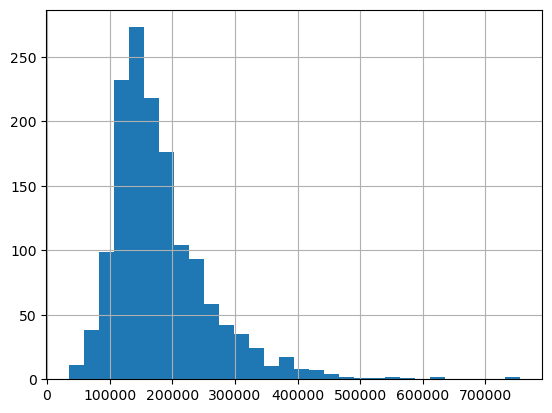

In [309]:
# checking the target column through histogram, bins = 30, grouped into 30 interval to see distribution
df["SalePrice"].hist(bins=30)

In [310]:
#Calculate correlations between all numerical features(that is all int\float column) and SalePrice, sort them from highest to lowest, and display the top 10.
df.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

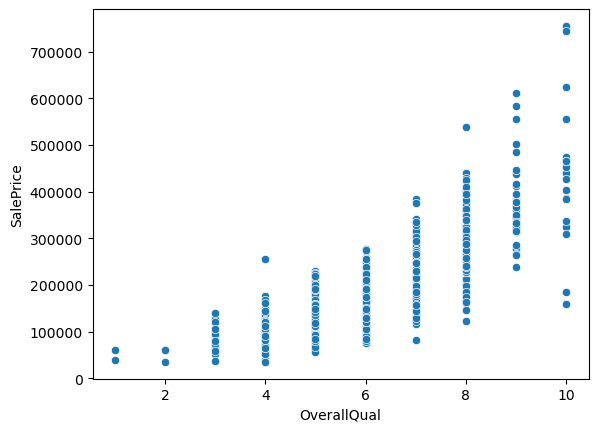

In [311]:
# Examine how house quality relates to SalePrice, Using scatter plot to Visualize the relationship between OverallQual and SalePrice.

sns.scatterplot(data=df, x="OverallQual", y="SalePrice")
plt.show()

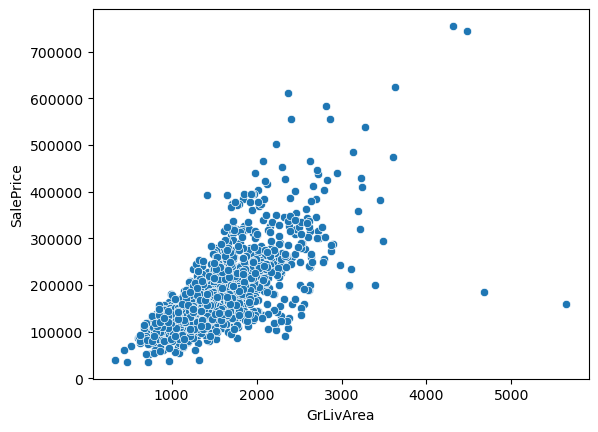

In [312]:
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")
plt.show()

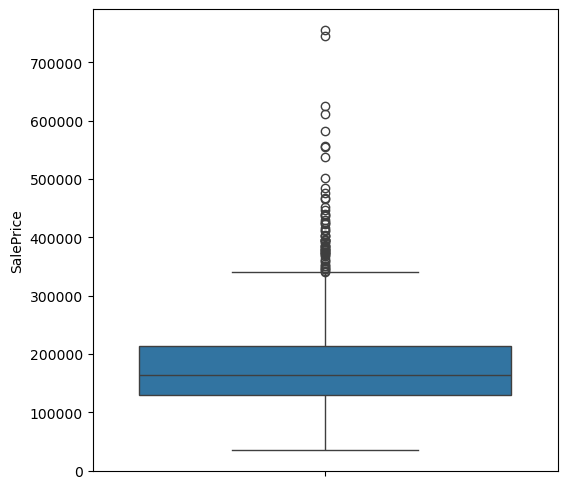

In [313]:
# using seaborn box plot , figsize of 6 width inches and 6 height tall inches
plt.figure(figsize=(6, 6))
sns.boxplot(y=df["SalePrice"])
plt.show()

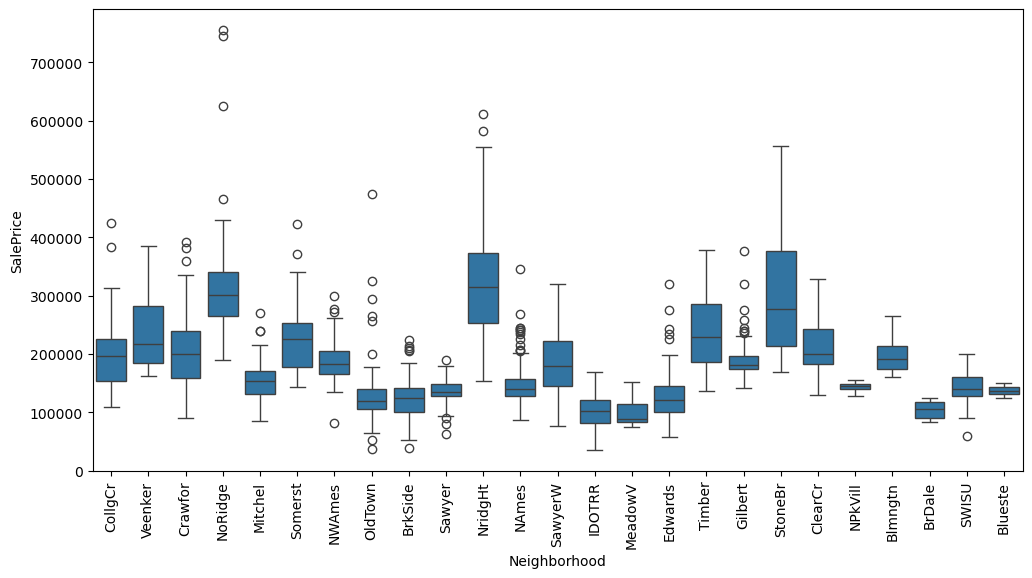

In [314]:
# Compare SalePrice distributions across different Neighborhoods using boxplot, figsize of 12 width inches and 6 height tall inches
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Neighborhood", y="SalePrice")
plt.xticks(rotation=90)
plt.show()

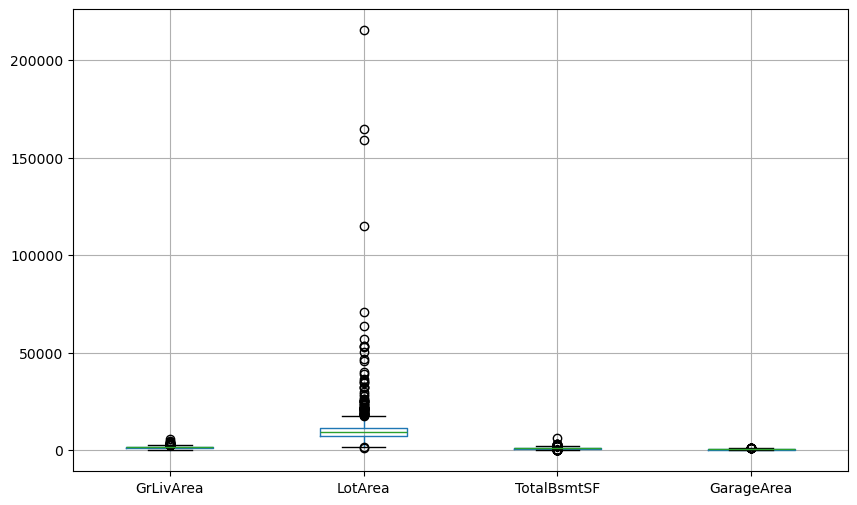

In [315]:
# Inspect the distribution and potential outliers in major numerical features.

df[["GrLivArea", "LotArea", "TotalBsmtSF", "GarageArea"]].boxplot(
    figsize=(10, 6)
)
plt.show()

## Separate Features X and Target Y

In [316]:
# how many object and ints do we have in the dataframe
df.dtypes.value_counts()

object     43
int64      34
float64     3
Name: count, dtype: int64

In [317]:
#gives us all the categorical\object columns we need to encode into numbers before feeding them to our regression model.
# because most regression algorithm model deals with numerical value or int\float execpt logistics regression

df.select_dtypes(include="object").columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [318]:
#Here we seprate our x and y by removing ["salesPrice"} from the dataframe and give it a variable of x
X = df.drop("SalePrice", axis=1)

#confirm the shape, now our x only contain 160, row and 79 column
X.shape

(1460, 79)

In [319]:
# then assigned the target back to a variable of y 
y = df["SalePrice"]

#confirm the shape, now our y only contain the single column ["salesPrice"} with 1460 row
y.shape

(1460,)

## Split Train and Test Data

In [320]:
# we import our ML library SkLearn, and select train test split from it ,it would allow us to test split our x,y into train\test set
from sklearn.model_selection import train_test_split

In [321]:
#here we splits our x, y into 80% : 20% ratio, 80% training data for learning and 20% testing data for evaluating the model,
#text_size = 0.2 means keep the test size 20% on each x,y
#random_state=42 makes sure we get the same split every time we run the code.

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

In [322]:
# the shape of our 80% x 
X_train.shape

(1168, 79)

In [323]:
# the shape of our 20% x
X_test.shape

(292, 79)

In [324]:
# the shape of our 80% y
y_train.shape

(1168,)

In [325]:
# the shape of our 20% y
y_test.shape

(292,)

## Preprocessing / Encoding

In [326]:
# this import lib allow us to preprocess and encoding, by changing categorical column to numerical value
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [327]:
#gives us all the categorical\object columns in x_train and wrapped into a varaible called categorical_features
categorical_features = X_train.select_dtypes(include="object").columns

#lets confirm the lenght
len(categorical_features)

43

In [328]:
#gives us all the existing numerical\int\float columns in x_train and wrapped into a varaible called numerical_features
numerical_features = X_train.select_dtypes(exclude="object").columns

#lets confirm the lenght
len(numerical_features)

36

In [329]:
# preprocessing system that keeps numerical features unchanged and converts categorical features into numerical values using One-Hot Encoding.
# So our preprocessor is simply a converter

preprocessor = ColumnTransformer( transformers=[ ("num", "passthrough", numerical_features),
                                                 ("cat", OneHotEncoder(handle_unknown="ignore"), 
                                                  categorical_features) ])

In [330]:
# here we created a variable (X_train_processed ) to wrap up or apply our conversions (categorical values into numbers)
X_train_processed = preprocessor.fit_transform(X_train)

In [331]:
#confirming the x_train shape after prepocssing  & encoding (we now have 300 column because of the encoding , previously it was 79)
X_train_processed.shape

(1168, 300)

In [332]:
# here we created a variable (X_test_processed) to wrap up or apply our conversions (categorical values into numbers) 
#but using the existing apply rules above to learned from the training data to transform the test data, we want it unseen so we use (.transform) only
X_test_processed = preprocessor.transform(X_test)

In [333]:
#confirming the x_test shape after prepocssing & encoding (we now have 300 column because of the encoding , previously it was 79)
X_test_processed.shape

(292, 300)

## Model Training, Prediction and Evaluation

#### Linear Regression Model

We will start with Linear Regression Algorithm as our baseline model, it use the training data to learn the relationship between the house features and `SalePrice`.
linear regression predicts a continous value using a strtaight line, this fit the price prediction and sales forecasting.

In [334]:
# importing the LinearRegression algorithm model
from sklearn.linear_model import LinearRegression

In [335]:
#created a variable called linear_model for the LR algorithm model
linear_model = LinearRegression()

In [336]:
# This will makes the model variable learn the relationship between the house features (x_train_processed) and SalePrice(y_train).
linear_model.fit(X_train_processed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [337]:
# Use the trained model to take the test features (X_test_processed) and predict their SalePrice, then store those predictions in a variable of  y_pred.
# using our reserved 20% feature df to test the model and predict using (linear_model.predict) then answer to be store into linear_pred variable
linear_pred = linear_model.predict(X_test_processed)

In [338]:
# our prediction , we have about 292 predicted house price here 
linear_pred

array([153699.53632567, 355633.53920322,  93613.96282371, 179817.71675832,
       342441.56477775,  62954.14628058, 253772.37820709, 154030.22563761,
        60465.19091816, 147887.32395782, 144434.68220167, 105062.65059368,
        96399.00519598, 229462.58412769, 172884.61279753, 137621.06328629,
       189038.65009838, 126792.30711003, 126314.23987921, 212661.55595371,
       161550.09151719, 202610.23635255, 176216.44656477, 134548.27653039,
       207563.13058335, 143985.13888055, 202207.16055849,  91231.58916154,
       170922.88627843, 210715.11215414, 117499.35668894, 266686.22224489,
       226179.22819833, 111742.8635881 , 251075.39581493, 145503.85918727,
       131501.07477416, 205295.62156991, 332744.41633368, 115953.30105827,
       137234.96443945, 227485.97200244, 105037.67349824, 342568.44307376,
       132925.45250914, 147150.92698307, 108980.07171525, 139489.36044445,
       401623.09637389, 126121.68430975, 123803.56784343, 240889.76106008,
        91781.8467851 , 2

##### MSE Mean Square Error metrics 1

In [339]:
#importing MSE metrics lib for metric 1 evaluation
from sklearn.metrics import mean_squared_error

In [340]:
#perform the calcuation of mse comparsion and store the result into linear_mse variable
linear_mse = mean_squared_error(y_test, linear_pred)

#checked result, we have 981,994,725.87
linear_mse

981994725.8701949

##### RMSE Root Mean Square Error metrics 2

In [341]:
#importing MSE metrics lib for metric 2 evaluation
from sklearn.metrics import mean_squared_error

In [342]:
# here we give rmse the parameter of linear-mse we gotten above to do more better intutive calculation, then store the result into linear_rmse variable
linear_rmse = np.sqrt(linear_mse)


#checked result, we have 31,336.80, this more better in terms of error gap close to our prediction or error magnitude
linear_rmse

np.float64(31336.79507974922)

In [343]:
#this table is fact-checking the model's predictions against the actual prices


#created a table and wrapped into a variable called comparison, The Actual price column comes from y_test, which contains the real SalePrice values 
#that were held back when we split the dataset and The Predicted column comes from linear_pred, which contains the model's predictions for those exact 
#same 292 houses.
comparison = pd.DataFrame({ "Actual price": y_test, "Predicted price": linear_pred})


#20 row table with those column
comparison.head(20)

,Actual price,Predicted price
892,154500,153699.536326
1105,325000,355633.539203
413,115000,93613.962824
522,159000,179817.716758
1036,315500,342441.564778
614,75500,62954.146281
218,311500,253772.378207
1160,146000,154030.225638
649,84500,60465.190918
887,135500,147887.323958


##### R² Score metrics 3

In [344]:
# import lib for r2 score,
from sklearn.metrics import r2_score

In [345]:
# perform the measurement variation and store the result into linear_r2 variable
linear_r2 = r2_score(y_test, linear_pred)


#checked result, we have approx 87.2% rate, that is, about 87.2% of the variation in the house prices in our test set is explained by the model 
# and about 12.8% not explained by our model
linear_r2

0.8719748418326639

#### Random Forest Regressor Model

We will use the Random Forest Regressor as our second model. It uses the training data to learn the relationship between the house features and SalePrice by combining multiple decision trees.

In [346]:
# importing the Random Forest Regressor Algorithm model
from sklearn.ensemble import RandomForestRegressor

In [347]:
#created a variable called rfr_model for the  RFR algorithm model and random state = 10 means Use the same random process every time I run this model
rfr_model = RandomForestRegressor(random_state=10)

In [348]:
# This will makes the model variable learn the relationship between the house features (x_train_processed) and SalePrice(y_train).
rfr_model.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [349]:
# Use the trained model to take the test features (X_test_processed) and predict their SalePrice, then store those predictions in a variable of rfr_pred.
# using our reserved 20% feature df to test the model and predict using (rfr_model.predict) then answer to be store into rfr_pred variable
rfr_pred = rfr_model.predict(X_test_processed)

In [350]:
# our prediction , we have about 292 predicted house price here 
rfr_pred

array([142358.25, 314388.8 , 116213.  , 158514.  , 322451.31,  84981.  ,
       216745.67, 150180.64,  85313.5 , 128097.27, 154534.94, 122511.83,
       110779.  , 210445.49, 177586.55, 131573.25, 197077.8 , 136380.  ,
       113985.  , 204663.37, 159848.23, 224554.63, 177265.9 , 121777.  ,
       196267.22, 172040.66, 185471.27, 105536.  , 177931.9 , 196048.08,
       124947.32, 248531.05, 168042.98, 114381.75, 255998.68, 148202.85,
       134801.82, 205033.45, 316108.3 , 108156.32, 123510.  , 236630.11,
       122098.33, 362852.68, 135495.43, 146178.47, 117916.83, 126381.  ,
       394496.84, 145369.34, 120511.  , 194507.64, 122436.54, 360149.73,
       140683.6 , 243982.73, 195545.08, 152384.85, 145072.02, 113620.16,
        76263.5 , 151189.87, 304453.9 , 270133.48, 281873.25, 210529.95,
       109663.  , 316412.79, 115945.55, 166435.18, 130757.84, 129056.14,
       114187.33,  90934.5 , 461354.27, 174029.74, 314051.43, 291787.75,
       137130.  , 122331.83, 100437.5 ,  93115.5 , 

##### MSE Mean Square Error metrics 1

In [351]:
#importing MSE metrics lib for metric 1 evaluation
from sklearn.metrics import mean_squared_error

In [352]:
#perform the calcuation of mse comparsion and store the result into rfr_mse variable
rfr_mse = mean_squared_error(y_test, rfr_pred)

In [353]:
#checked result, we have 877,120,790

rfr_mse

877120790.96264

##### RMSE Root Mean Square Error metrics 2

In [354]:
#importing MSE metrics lib for metric 2 evaluation
from sklearn.metrics import mean_squared_error

In [355]:
# here we give rmse the parameter of rfr_mse we gotten above to do more better intutive calculation, then store the result into rfr_rmse variable
rfr_rmse = np.sqrt(rfr_mse)

In [356]:
#checked result, we have 29,616, this is more better in terms of error gap close to our prediction or error magnitude
rfr_rmse

np.float64(29616.225130199156)

##### R² Score metrics 3

In [357]:
# import lib for r2 score,
from sklearn.metrics import r2_score

In [358]:
# perform the measurement variation and store the result into rfr_r2 variable
rfr_r2 = r2_score(y_test, rfr_pred)

In [359]:
#checked result, we have approx 88.5% rate, that is, about 88.5% of the variation in the house prices in our test set is explained by the model 
# and about 11.5% not explained by our model
rfr_r2

0.8856475243333491

#### Gradient Boosting Regressor Model

We will use Gradient Boosting Regressor as our third model. It builds multiple decision trees sequentially, where each new tree focuses on correcting the errors made by the previous trees.

In [364]:
# importing the Gradient Boosting Regressor Algorithm model
from sklearn.ensemble import GradientBoostingRegressor

In [365]:
#created a variable called gbr_model for the gbr algorithm model and random state = 10 means Use the same random process every time I run this model
gbr_model = GradientBoostingRegressor(random_state=10)

In [366]:
# This will makes the model variable learn the relationship between the house features (x_train_processed) and SalePrice(y_train).
gbr_model.fit(X_train_processed, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [368]:
# Use the trained model to take the test features (X_test_processed) and predict their SalePrice, then store those predictions in a variable of gbr_pred.
# using our reserved 20% feature df to test the model and predict using (gbr_model.predict) then answer to be store into gbr_pred variable
gbr_pred = gbr_model.predict(X_test_processed)

In [369]:
# our prediction , we have about 292 predicted house price here 
gbr_pred

array([143221.34876592, 340266.04110248, 122607.31811135, 151011.41037876,
       332283.04229354,  82184.53087909, 230709.67226791, 146376.79627288,
        79797.06789511, 138198.27227042, 156135.8288759 , 124603.51576634,
       115822.01648984, 203223.91561312, 166785.58360226, 135855.29487091,
       194016.19108394, 136399.082511  , 117567.13489578, 209343.60582385,
       154112.30939073, 215759.97080246, 169632.19157689, 126412.70250092,
       198713.0294723 , 169627.88399294, 191120.51760551, 113423.84676023,
       173392.89164055, 191212.65237352, 124025.87442958, 254203.44915607,
       204926.01741464, 115361.23033009, 250573.35982148, 149479.88088693,
       134215.32417619, 205993.91217395, 317148.58657376, 120834.27390885,
       125758.86219509, 243627.40762231, 114367.60325042, 375252.72108166,
       125232.43607112, 130016.04404231, 114938.55105589, 131818.6996889 ,
       422856.28850434, 131612.33575988, 123391.12095682, 197783.86639008,
       112131.3251845 , 3

In [ ]:
After we got our prediction for Gradient Boosting Regressor, we perfom the evaluation metrics

##### MSE Mean Square Error metrics 1

In [ ]:
#importing MSE metrics lib for metric 1 evaluation
from sklearn.metrics import mean_squared_error

In [370]:
#perform the calcuation of mse comparsion and store the result into gbr_mse variable
gbr_mse = mean_squared_error(y_test, gbr_pred)

In [371]:
#checked result, we have 829,127,638
gbr_mse

829127638.8121805

##### RMSE Root Mean Square Error metrics 2

In [374]:
#importing MSE metrics lib for metric 2 evaluation
from sklearn.metrics import mean_squared_error

In [375]:
# here we give rmse the parameter of gbr_mse we gotten above to do more better intutive calculation, then store the result into gbr_rmse variable
gbr_rmse = np.sqrt(gbr_mse)

In [376]:
#checked result, we have 28,794, this is more better in terms of error gap close to our prediction or error magnitude
gbr_rmse

np.float64(28794.576552055434)

##### R² Score metrics 3

In [378]:
# import lib for r2 score,
from sklearn.metrics import r2_score

In [377]:
# perform the measurement variation and store the result into gbr_r2 variable
gbr_r2 = r2_score(y_test, gbr_pred)

In [379]:
#checked result, we have approx 89.2% rate, that is, about 88.5% of the variation in the house prices in our test set is explained by the model 
# and about 10.9% not explained by our model
gbr_r2

0.891904514043316

## Model Comparison and Improvement

In [383]:
# here we created our table for comparison through pd.dataframe, output will be stack all the model name and metrics in column while row contain metrics value
model_comparison = pd.DataFrame({
   
    "Model": [ "Linear Regression", "Random Forest","Gradient Boosting"],
    
    "MSE": [ linear_mse, rfr_mse, gbr_mse  ],
    
    "RMSE": [ linear_rmse, rfr_rmse, gbr_rmse ],
    
    "R²": [linear_r2, rfr_r2, gbr_r2]
})

#display the table
model_comparison

,Model,MSE,RMSE,R²
0,Linear Regression,9.819947e+08,31336.795080,0.871975
1,Random Forest,8.771208e+08,29616.225130,0.885648
2,Gradient Boosting,8.291276e+08,28794.576552,0.891905


#### Random Forest Regressor tuning

In [385]:
# for tuning: importing the Random Forest Regressor Algorithm model 

from sklearn.ensemble import RandomForestRegressor

In [403]:
# Create a tuned Random Forest Regressor by adjusting its hyperparameters

rfr_tuned = RandomForestRegressor(
    n_estimators=300,       # How many trees? Use 300 decision
    max_depth=None,         # How deep can each tree grow? Allow each tree to grow without a fixed depth limit
    min_samples_split=2,    #  When can a node split? → With at least 2 samples
    min_samples_leaf=1,     # Smallest final group? → 1 sample
    random_state=10         # Keep the random process consistent → same result each run
)

In [387]:
# Fitting : making the model variable to learn the relationship between the house features (x_train_processed) and SalePrice(y_train).
rfr_tuned.fit(X_train_processed, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [388]:
# Use the trained model to take the test features (X_test_processed) and predict their SalePrice, then store those predictions in a variable of rfr_tuned_pred.
# using our reserved 20% feature df to test the model and predict using (rfr_tuned.predict) then answer to be store into rfr_tuned_pred variable
rfr_tuned_pred = rfr_tuned.predict(X_test_processed)


In [404]:
# our prediction , we have about 292 predicted house price here 
rfr_tuned_pred

array([141238.91666667, 322564.37      , 116547.25      , 156911.5       ,
       316553.74666667,  86134.66666667, 213766.02666667, 152052.26      ,
        86214.99666667, 127418.16      , 156809.69333333, 121201.77333333,
       108989.33333333, 207110.35      , 178835.68333333, 131741.83333333,
       195658.82333333, 136285.08333333, 115403.        , 205716.57333333,
       160877.32333333, 224273.05666667, 176204.63      , 122949.47666667,
       195194.68333333, 172507.39333333, 185191.39      , 107183.12333333,
       178218.33      , 194643.06      , 124045.30666667, 247395.43      ,
       168052.84333333, 113955.41666667, 257622.45      , 147160.24      ,
       137820.93666667, 203726.73      , 316362.18      , 107907.15666667,
       123008.66666667, 236489.91      , 120775.33      , 367370.75      ,
       135614.01      , 148076.94      , 117632.94      , 127614.83333333,
       386180.52666667, 147518.23666667, 120627.54      , 194158.88      ,
       124956.72333333, 3

###### MSE, RMSE and R² Metrics

In [405]:
# using all the 3 metrics here all together , to avoid clutter, each metrics should be stored in a variables of rf_tuned_mse, rfr_tune_rmse, rfr_tuned_r2
rfr_tuned_mse = mean_squared_error(y_test, rfr_tuned_pred)
rfr_tuned_rmse = np.sqrt(rfr_tuned_mse)
rfr_tuned_r2 = r2_score(y_test, rfr_tuned_pred)

# print result, one after the other and show print with decimal & comma 
print(f"MSE: {rfr_tuned_mse:,.2f}")
print(f"RMSE: {rfr_tuned_rmse:,.2f}")
print(f"R²: {rfr_tuned_r2:.4f}")

MSE: 840,487,280.95
RMSE: 28,991.16
R²: 0.8904


#### Gradient Boosting Regressor tuning

In [412]:
# for tuning: importing the Gradient Boosting Regressor Algorithm model 
from sklearn.ensemble import GradientBoostingRegressor

In [413]:
# Create a tuned Gradient Boosting Regressor by adjusting its hyperparameters
gbr_tuned = GradientBoostingRegressor(
    n_estimators=300,      # # How many trees? Use 300 decision trees
    learning_rate=0.05,   # How strongly does each tree correct the model? Small steps of 0.05 or Controls how much each tree contributes to the model
    max_depth=3,          # How complex can each tree become? Maximum depth of 3 or Limit each tree to a maximum depth of 3
    random_state=10       # # Keep the random process consistent,same result each run
)

In [414]:
# Fitting : making the model variable to learn the relationship between the house features (x_train_processed) and SalePrice(y_train).
gbr_tuned.fit(X_train_processed, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [415]:
# Use the trained model to take the test features (X_test_processed) and predict their SalePrice, then store those predictions in a variable of gbr_tuned_pred.
# using our reserved 20% feature df to test the model and predict using (gbr_tuned.predict) then answer to be store into gbr_tuned_pred variable
gbr_tuned_pred = gbr_tuned.predict(X_test_processed)

In [397]:
# our prediction , we have about 292 predicted house price here 
gbr_tuned_pred

array([141238.91666667, 322564.37      , 116547.25      , 156911.5       ,
       316553.74666667,  86134.66666667, 213766.02666667, 152052.26      ,
        86214.99666667, 127418.16      , 156809.69333333, 121201.77333333,
       108989.33333333, 207110.35      , 178835.68333333, 131741.83333333,
       195658.82333333, 136285.08333333, 115403.        , 205716.57333333,
       160877.32333333, 224273.05666667, 176204.63      , 122949.47666667,
       195194.68333333, 172507.39333333, 185191.39      , 107183.12333333,
       178218.33      , 194643.06      , 124045.30666667, 247395.43      ,
       168052.84333333, 113955.41666667, 257622.45      , 147160.24      ,
       137820.93666667, 203726.73      , 316362.18      , 107907.15666667,
       123008.66666667, 236489.91      , 120775.33      , 367370.75      ,
       135614.01      , 148076.94      , 117632.94      , 127614.83333333,
       386180.52666667, 147518.23666667, 120627.54      , 194158.88      ,
       124956.72333333, 3

###### MSE, RMSE and R² Metrics

In [416]:
# using all the 3 metrics here all together , to avoid clutter, each metrics should be stored in a variables of rf_tuned_mse, rfr_tune_rmse, rfr_tuned_r2
gbr_tuned_mse = mean_squared_error(y_test, gbr_tuned_pred)
gbr_tuned_rmse = np.sqrt(gbr_tuned_mse)
gbr_tuned_r2 = r2_score(y_test, gbr_tuned_pred)


# print result, one after the other and show print with decimal & comma 
print(f"MSE: {gbr_tuned_mse:,.2f}")
print(f"RMSE: {gbr_tuned_rmse:,.2f}")
print(f"R²: {gbr_tuned_r2:.4f}")

MSE: 687,982,979.88
RMSE: 26,229.43
R²: 0.9103


## Final Model and New Predictions

In [421]:
# Created Dicts Table using pd.dataframe that show all models metrics result (MSE, RMSE, and R²)

final_comparison = pd.DataFrame({
    "Model": [ "Linear Regression",  "Random Forest",  "Tuned Random Forest",  "Gradient Boosting",  "Tuned Gradient Boosting"  ],
    
    "MSE": [  linear_mse,  rfr_mse,  rfr_tuned_mse,   gbr_mse, gbr_tuned_mse ],
    
    "RMSE": [ linear_rmse, rfr_rmse,  rfr_tuned_rmse,  gbr_rmse,  gbr_tuned_rmse ],
    
    "R²": [  linear_r2, rfr_r2, rfr_tuned_r2, gbr_r2, gbr_tuned_r2]
})

final_comparison

,Model,MSE,RMSE,R²
0,Linear Regression,9.819947e+08,31336.795080,0.871975
1,Random Forest,8.771208e+08,29616.225130,0.885648
2,Tuned Random Forest,8.404873e+08,28991.158669,0.890424
3,Gradient Boosting,8.291276e+08,28794.576552,0.891905
4,Tuned Gradient Boosting,6.879830e+08,26229.429652,0.910306


In [445]:
# we stored the achieved final model into a varibale called final model
final_model = gbr_tuned

In [422]:
# importing and load our second dataset we preserved for testing, store it in a varibale called test_df
# we will be using this to test our final model
test_df = pd.read_csv("test.csv")

In [423]:
# checking out the shape , we have 1,459 row and 80 colum (same shape as the original train.csv too)
test_df.shape

(1459, 80)

In [432]:
# We are going  to do all the cleaning for test_df in the same line cell to avoid clutter, since we already figured our fillna,median, mode, it recommended

# Using For loops condition :
#loop around all the test_df, if any null in row, chnage it to 0, 
#if any datatype is object, change it to mode, median int\float base on df.describe result (we need numerical value all through)
for col in test_df.columns:
    if test_df[col].isnull().sum() > 0:
        if test_df[col].dtype == "object":
            test_df[col] = test_df[col].fillna(test_df[col].mode()[0])
        else:
            test_df[col] = test_df[col].fillna(test_df[col].median())

In [434]:
#verifying if no more null\missing value remains in th dataset before Preeprocessing and Encoding (zero remain)
test_df.isnull().sum().sum()

np.int64(0)

In [437]:
#Preeprocessing and stored it in a variable called test_processed
test_processed = preprocessor.transform(test_df)

In [442]:
test_processed.shape

(1459, 300)

##### New Prediction

In [446]:
# We are predicting new house using the test dataset we just cleaned and preprocessed (test_processed), using our gbr_tuned we later changed to final_model
# and to be stored in a variable called final_predictions
final_predictions = final_model.predict(test_processed)

In [448]:
# through slashing, show me the first 10 predicted result
final_predictions[:10]

array([125052.29708442, 166717.83249528, 175730.1824595 , 187484.41859096,
       193589.08807652, 173937.43784894, 170485.059781  , 164117.09639181,
       184621.769373  , 121313.81156767])

##### Prediction Export

Now we need to create the file containing the required Id and the final prediction(SalePrice)

In [451]:
#Created a table using all the id found in test.csv and match it with the new predictions using sales prices as column name
#then store it in a variable called submission
submission = pd.DataFrame({ "Id": pd.read_csv("test.csv")["Id"], "SalePrice": final_predictions})

In [453]:
#checking our pd.dataframe table we just created,extract the first 10
submission.head(10)

,Id,SalePrice
0,1461,125052.297084
1,1462,166717.832495
2,1463,175730.182459
3,1464,187484.418591
4,1465,193589.088077
5,1466,173937.437849
6,1467,170485.059781
7,1468,164117.096392
8,1469,184621.769373
9,1470,121313.811568


In [452]:
# Saved into CSV and with No indexing
submission.to_csv("submission.csv", index=False)

## Deployment

In [ ]:
We will save the final model and preprocessing pipeline so they can be loaded later to make predictions on new house data.

In [454]:
# Import joblib to save and load our trained model and preprocessor engine
import joblib

In [456]:
# dump & save the final model into pkl file as house_price_model.pkl (for backend or fastAPI purposes)
joblib.dump(final_model, "house_price_model.pkl")

['house_price_preprocessor.pkl']

In [467]:
# dump & save the preprocessing system engine we used to transform the house data,into pkl file as house_price_preprocessor_.pkl (for backend or fastAPI purposes)
joblib.dump(preprocessor, "house_price_preprocessor.pkl")

['house_price_preprocessor.pkl']

In [457]:
# Import OS to work with files and folders in the operating system
import os

In [468]:
# List all files and folders in the current working directory
os.listdir()

['.ipynb_checkpoints',
 'data_description.txt',
 'house_price_model.pkl',
 'House_Price_Prediction.ipynb',
 'house_price_preprocessor.pkl',
 'submission.csv',
 'test.csv',
 'train.csv']

In [470]:
# for Model
loaded_model = joblib.load("house_price_model.pkl")

# verifying
type(loaded_model)

sklearn.ensemble._gb.GradientBoostingRegressor

In [471]:
# For Preprocessor engine
loaded_preprocessor = joblib.load("house_price_preprocessor.pkl")

# verifying
type(loaded_preprocessor)

sklearn.compose._column_transformer.ColumnTransformer

In [463]:
# creating prediction function for reuseable
def predict_house_price(new_house):
    new_house_processed = loaded_preprocessor.transform(new_house)
    prediction = loaded_model.predict(new_house_processed)
    return prediction

In [464]:
#Take the first house (row 0) from X_test and store it as new_house.
new_house = X_test.iloc[[0]]

#checking shape of the df, we have 1 row, 79 column
new_house.shape

(1, 79)

In [466]:
# prediction for the new house happen here, 145,974
predict_house_price(new_house)

array([145974.19286992])

In [472]:
# Compare the model's predicted price with the actual house price
actual_price = y_test.iloc[0] #retrieved [0]takes the first value or item,from y_test, the 20% data splitted from the df for testing
predicted_price = predict_house_price(new_house)[0]

print(f"Actual price: ${actual_price:,.2f}")
print(f"Predicted price: ${predicted_price:,.2f}")

Actual price: $154,500.00
Predicted price: $145,974.19


Our final model achieved an R² of 0.9103, meaning it explains about 91.03% of the variation in house prices in our test set. Its typical prediction error, measured by RMSE, is about $26,229.